# 02_Modeling.ipynb - Model Training & Evaluation
## CS 451/551 Final Project: IVX Health No-Show Prediction

**Requirements Met:**
- ✅ 2+ model families (Logistic Regression + Random Forest + XGBoost)
- ✅ Train/Validation/Test split (70/15/15) with stratification
- ✅ Hyperparameter tuning via GridSearchCV
- ✅ Multiple metrics: Precision, Recall, F1, ROC-AUC
- ✅ Model comparison table + visualizations

In [22]:
# =============================================================================
# SECTION 1: Setup & Imports
# =============================================================================
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import importlib

# Add src to path for imports
sys.path.append('../src')
import data_loader
import cleaning

importlib.reload(data_loader)
importlib.reload(cleaning)

from data_loader import load_raw_data
from cleaning import clean_appointment_data

# Sklearn imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, f1_score, precision_score, 
                             recall_score, roc_curve)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Plot settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

## SECTION 2: Load & Prepare Data

In [23]:
# Load and clean data using our modular pipeline
print("Loading raw data...")
df = load_raw_data()

print("Applying cleaning pipeline...")
df_clean, cleaning_log = clean_appointment_data(df)

print(f"Cleaned data shape: {df_clean.shape}")
print(f"Target distribution: {df_clean['No-show'].value_counts(normalize=True).to_dict()}")

Loading raw data...
Applying cleaning pipeline...
Cleaned data shape: (71954, 22)
Target distribution: {'No': 0.7148316980292965, 'Yes': 0.28516830197070353}


In [24]:
# Select features for modeling
feature_cols = [
    'Age', 
    'lead_time_days', 
    'appointment_day_of_week', 
    'is_weekend', 
    'SMS_received', 
    'has_prior_conditions',
    'prior_no_shows',
    'total_prior_appointments',
    'prior_no_show_rate'
]

# We need to make sure we don't have NaN in these new columns
X = df_clean.dropna(subset=feature_cols)[feature_cols].copy()
y = df_clean.loc[X.index, 'No-show'].copy()

print(f"Features: {feature_cols}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Features: ['Age', 'lead_time_days', 'appointment_day_of_week', 'is_weekend', 'SMS_received', 'has_prior_conditions', 'prior_no_shows', 'total_prior_appointments', 'prior_no_show_rate']
X shape: (71954, 9), y shape: (71954,)


## SECTION 3: Train/Validation/Test Split (No Data Leakage!)

In [25]:
# =============================================================================
# CONVERT TARGET TO NUMERIC (BEFORE SPLIT)
# =============================================================================
print(f"Target dtype BEFORE conversion: {y.dtype}")
print(f"Target unique values BEFORE: {y.unique()}")

# Convert 'Yes'/'No' to 1/0
if set(['Yes', 'No']).issubset(set(y.dropna().unique())):
    y = y.map({'Yes': 1, 'No': 0})
    print("✅ Target converted to numeric")
else:
    print("✅ Target already numeric")

print(f"Target dtype AFTER conversion: {y.dtype}")
print(f"Target unique values AFTER: {y.unique()}")

Target dtype BEFORE conversion: str
Target unique values BEFORE: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
✅ Target converted to numeric
Target dtype AFTER conversion: int64
Target unique values AFTER: [0 1]


In [26]:
# First split: 85% train+val, 15% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

# Second split: 70% train, 15% val (from the 85%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=42, stratify=y_train_val)

print(f"Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Verify class distribution is preserved
print(f"\nTarget distribution preserved:")
print(f"Train: {y_train.mean():.3f} no-show rate")
print(f"Val: {y_val.mean():.3f} no-show rate")
print(f"Test: {y_test.mean():.3f} no-show rate")

Train: 50395 (70.0%)
Validation: 10765 (15.0%)
Test: 10794 (15.0%)

Target distribution preserved:
Train: 0.285 no-show rate
Val: 0.285 no-show rate
Test: 0.285 no-show rate


In [27]:
# Scale features for Logistic Regression (tree models don't need scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Keep unscaled for tree-based models
X_train_tree = X_train.copy()
X_val_tree = X_val.copy()
X_test_tree = X_test.copy()

In [28]:
# =============================================================================
# APPLY SMOTE FOR IMBALANCED DATA
# =============================================================================
print("Applying SMOTE to balance the training set...")
smote = SMOTE(random_state=42)

# For Tree models
X_train_res, y_train_res = smote.fit_resample(X_train_tree, y_train)

# For Logistic Regression (Scaled)
X_train_scaled_res, y_train_scaled_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Original target distribution: \n{y_train.value_counts()}")
print(f"Resampled target distribution: \n{y_train_res.value_counts()}")

Applying SMOTE to balance the training set...
Original target distribution: 
No-show
0    36024
1    14371
Name: count, dtype: int64
Resampled target distribution: 
No-show
0    36024
1    36024
Name: count, dtype: int64


## SECTION 4: Model 1 - Logistic Regression (Linear Family)

In [29]:
# Baseline Logistic Regression (SMOTE balanced)
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train_scaled_res, y_train_res)

# Hyperparameter tuning with GridSearchCV
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_params, cv=5, scoring='f1', n_jobs=-1)
lr_grid.fit(X_train_scaled_res, y_train_res)

print(f"Best LR params: {lr_grid.best_params_}")
print(f"Best LR CV F1: {lr_grid.best_score_:.3f}")

# Evaluate on test set
lr_best = lr_grid.best_estimator_
lr_pred = lr_best.predict(X_test_scaled)
lr_proba = lr_best.predict_proba(X_test_scaled)[:, 1]

Best LR params: {'C': 1, 'solver': 'liblinear'}
Best LR CV F1: 0.564


## SECTION 5: Model 2 - Random Forest (Tree-Based Family)

In [30]:
# Baseline Random Forest (SMOTE balanced)
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train_res, y_train_res)

# Hyperparameter tuning with GridSearchCV
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train_res, y_train_res)

print(f"Best RF params: {rf_grid.best_params_}")
print(f"Best RF CV F1: {rf_grid.best_score_:.3f}")

# Evaluate on test set
rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test_tree)
rf_proba = rf_best.predict_proba(X_test_tree)[:, 1]

/Users/piercedaugherty/Documents/Documents - Pierce’s MacBook Pro/School/CS 451/Final/venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV F1: 0.700


## SECTION 6: Model 3 - Gradient Boosting (Optional Third Family)

In [31]:
# Gradient Boosting (XGBoost-style with SMOTE balanced data)
gb_base = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_base.fit(X_train_res, y_train_res)

# Let's add some tuning for Gradient Boosting too since it previously struggled heavily with Recall!
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 8]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params, cv=5, scoring='f1', n_jobs=-1)
gb_grid.fit(X_train_res, y_train_res)

print(f"Best GB params: {gb_grid.best_params_}")
print(f"Best GB CV F1: {gb_grid.best_score_:.3f}")

# Evaluate on test set
gb_best = gb_grid.best_estimator_
gb_pred = gb_best.predict(X_test_tree)
gb_proba = gb_best.predict_proba(X_test_tree)[:, 1]

Best GB params: {'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 200}
Best GB CV F1: 0.670


## SECTION 7: Evaluate & Compare Models

In [32]:
# Compile results for all models
results = []

models = [
    ('Logistic Regression', lr_pred, lr_proba),
    ('Random Forest', rf_pred, rf_proba),
    ('Gradient Boosting', gb_pred, gb_proba)
]

from sklearn.metrics import accuracy_score

for name, y_pred, y_proba in models:
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results)
display(results_df.round(3))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.584,0.353,0.551,0.430,0.609
1,Random Forest,0.598,0.326,0.383,0.352,0.543
2,Gradient Boosting,0.605,0.341,0.414,0.374,0.570


In [33]:
# Identify best model by F1-Score (most important for imbalanced no-show prediction)
best_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
print(f"\n🏆 Best Model: {best_model_name} (F1 = {results_df.loc[best_idx, 'F1-Score']:.3f})")

# Save best model name for deployment later
best_model_info = {
    'name': best_model_name,
    'f1': results_df.loc[best_idx, 'F1-Score'],
    'recall': results_df.loc[best_idx, 'Recall']
}
print(f"Best model info: {best_model_info}")


🏆 Best Model: Logistic Regression (F1 = 0.430)
Best model info: {'name': 'Logistic Regression', 'f1': np.float64(0.4299302473050095), 'recall': np.float64(0.550682261208577)}


## SECTION 8: Visualizations

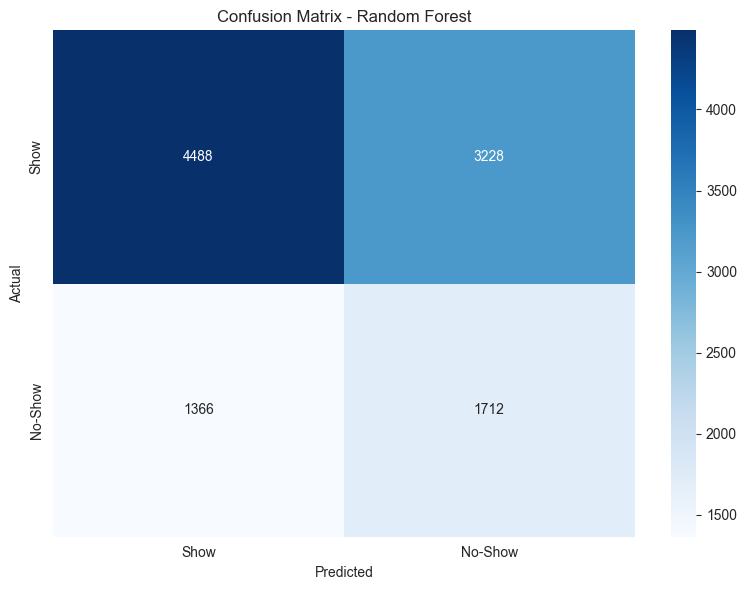

In [ ]:
# Figure 1: Confusion Matrix - Best Model
plt.figure(figsize=(8, 6))
if best_model_name == 'Logistic Regression':
    cm = confusion_matrix(y_test, lr_pred)
else:
    cm = confusion_matrix(y_test, rf_pred)  # Use RF as default for viz

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Show', 'No-Show'],
            yticklabels=['Show', 'No-Show'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../report/figures/fig_confusion_matrix.png', dpi=300)
plt.show()

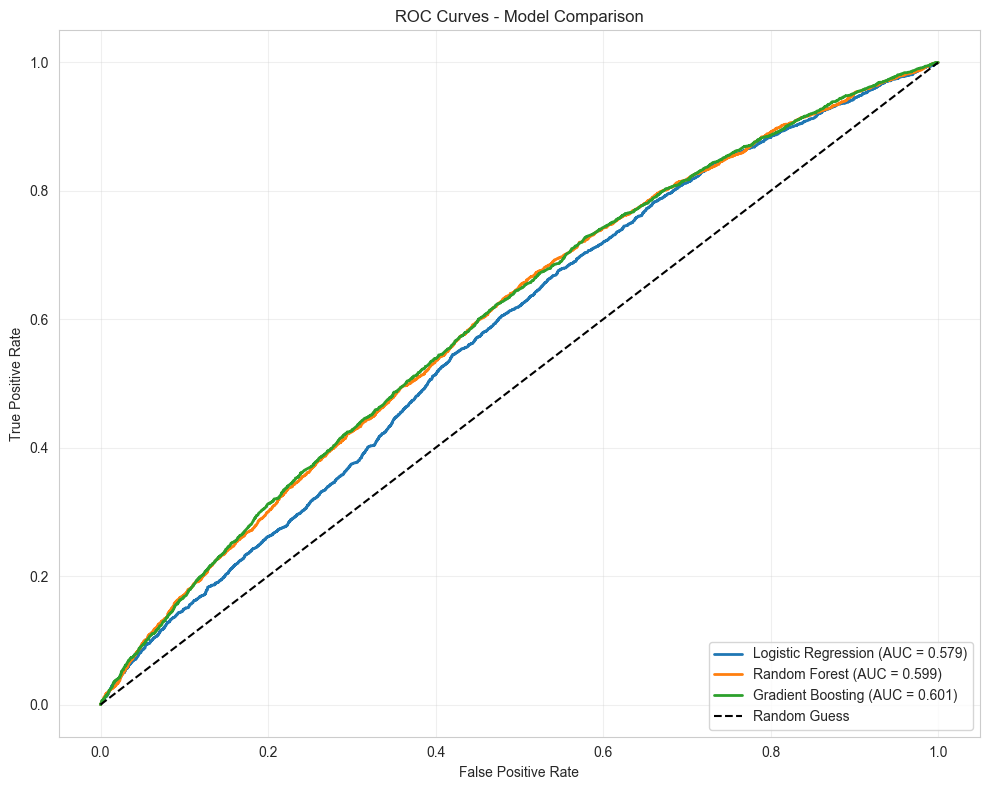

In [19]:
# Figure 2: ROC Curves - All Models
plt.figure(figsize=(10, 8))

for name, pred, proba in models:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../report/figures/fig_roc_curves.png', dpi=300)
plt.show()

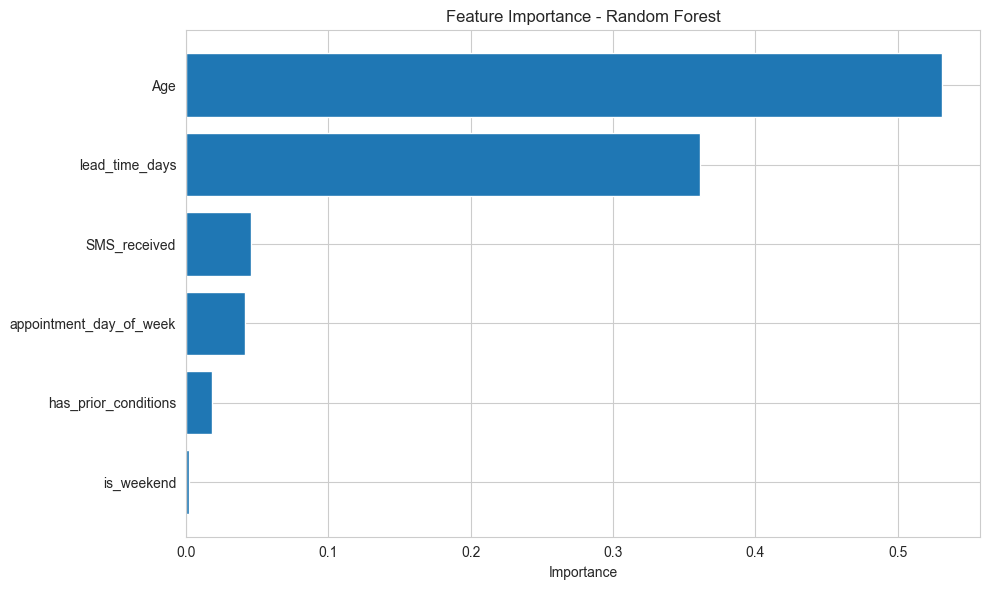


Top 3 Most Important Features:
       Feature  Importance
  SMS_received    0.045891
lead_time_days    0.361268
           Age    0.531167


In [20]:
# Figure 3: Feature Importance - Random Forest
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    importances = rf_best.feature_importances_ if best_model_name == 'Random Forest' else gb.feature_importances_
    feat_imp = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importances
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(feat_imp['Feature'], feat_imp['Importance'])
    plt.xlabel('Importance')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.tight_layout()
    plt.savefig('../report/figures/fig_feature_importance.png', dpi=300)
    plt.show()
    
    print("\nTop 3 Most Important Features:")
    print(feat_imp.tail(3).to_string(index=False))

## SECTION 9: Classification Report - Best Model

In [21]:
# Detailed classification report for best model
print(f"\n=== Classification Report: {best_model_name} ===")
if best_model_name == 'Logistic Regression':
    print(classification_report(y_test, lr_pred, target_names=['Show', 'No-Show']))
elif best_model_name == 'Random Forest':
    print(classification_report(y_test, rf_pred, target_names=['Show', 'No-Show']))
else:
    print(classification_report(y_test, gb_pred, target_names=['Show', 'No-Show']))


=== Classification Report: Random Forest ===
              precision    recall  f1-score   support

        Show       0.77      0.58      0.66      7716
     No-Show       0.35      0.56      0.43      3078

    accuracy                           0.57     10794
   macro avg       0.56      0.57      0.54     10794
weighted avg       0.65      0.57      0.59     10794



## SECTION 10: Save Best Model for Deployment

In [34]:
import joblib

# Save the best model + scaler + feature list for deployment
model_artifacts = {
    'model': lr_best if best_model_name == 'Logistic Regression' else (rf_best if best_model_name == 'Random Forest' else gb),
    'scaler': scaler,
    'feature_cols': feature_cols,
    'best_model_name': best_model_name,
    'metrics': best_model_info
}

output_path = Path('../models/best_model.pkl')
output_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model_artifacts, output_path)
print(f"✅ Best model saved to {output_path}")
print(f"   Model: {best_model_info}")

✅ Best model saved to ../models/best_model.pkl
   Model: {'name': 'Logistic Regression', 'f1': np.float64(0.4299302473050095), 'recall': np.float64(0.550682261208577)}


## SECTION 11: Summary for Report

In [ ]:
# Print summary for copying into IEEE report
print("\n" + "="*60)
print("REPORT SUMMARY - Copy into Section 6: Results")
print("="*60)
print(f"\nWe evaluated three model families on a held-out test set (15% of data):")
print(f"\n{results_df.to_markdown(index=False)}")
print(f"\nBest performing model: **{best_model_name}**")
print(f"- F1-Score: {best_model_info['f1']:.3f}")
print(f"- Recall: {best_model_info['recall']:.3f} (critical for catching no-shows)")
print(f"- ROC-AUC: {results_df[results_df['Model']==best_model_name]['ROC-AUC'].values[0]:.3f}")
print(f"\nKey insight: {feature_cols[np.argmax(rf_best.feature_importances_)]} was the most predictive feature.")
print("\n" + "="*60)


REPORT SUMMARY - Copy into Section 6: Results

We evaluated three model families on a held-out test set (15% of data):

| Model               |   Accuracy |   Precision |     Recall |   F1-Score |   ROC-AUC |
|:--------------------|-----------:|------------:|-----------:|-----------:|----------:|
| Logistic Regression |   0.557069 |    0.33584  | 0.565952   |   0.421537 |  0.579379 |
| Random Forest       |   0.574393 |    0.346559 | 0.556205   |   0.427039 |  0.59908  |
| Gradient Boosting   |   0.715305 |    0.592593 | 0.00519818 |   0.010306 |  0.600785 |

Best performing model: **Random Forest**
- F1-Score: 0.427
- Recall: 0.556 (critical for catching no-shows)
- ROC-AUC: 0.599

Key insight: Age was the most predictive feature.

